<a href="https://colab.research.google.com/github/weagan/In-Context-Learning/blob/main/ICL_vs_ICRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 In-Context Learning (ICL) vs. In-Context Reinforcement Learning (ICRL)

This notebook walks through a clear, side-by-side comparison of two paradigms:

| | **ICL** | **ICRL** |
|---|---|---|
| **What it is** | Show examples → model mimics them | Model tries actions → gets feedback → adapts |
| **Learning signal** | Pattern matching from demonstrations | Reward signal from outcomes |
| **Adaptation style** | Static: examples given once | Dynamic: updates behavior across episodes |
| **Analogy** | Reading a recipe | Cooking by trial and error |

We'll demonstrate both on a simple task: **guessing a secret number** 🎲


## 📦 Install Dependencies

In [ ]:
!pip install numpy matplotlib pandas --quiet

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import random
from IPython.display import display, HTML

random.seed(42)
np.random.seed(42)

print('✅ Imports ready!')

✅ Imports ready!


---
## 🔵 Part 1: In-Context Learning (ICL)

**Core idea:** You give the model a few (input → output) examples *in the prompt*. The model picks up the pattern and applies it to a new input — **no weight updates, no training**.

### How it works:
```
Prompt:
  Input: 3  → Output: high
  Input: 7  → Output: low
  Input: 5  → Output: ???
```

The model infers the rule from examples and predicts. It does this **once** — there's no loop, no feedback, no adaptation.

### Key properties:
- ✅ Fast — just craft a good prompt
- ✅ No gradient updates
- ❌ Can't correct mistakes from feedback
- ❌ Performance depends entirely on quality of examples provided

In [ ]:
# ─────────────────────────────────────────────
# IN-CONTEXT LEARNING DEMO
# Task: Guess if a number is "high" (>=5) or "low" (<5)
# The model is given k examples and then tested on new inputs.
# ─────────────────────────────────────────────

def true_label(x):
    """Ground truth: >=5 is 'high', <5 is 'low'."""
    return 'high' if x >= 5 else 'low'


def icl_predict(test_input, demonstrations):
    """
    Simulates an ICL 'model':
    - Looks at the given demonstrations
    - Finds the nearest neighbor in the demo set
    - Returns its label (majority vote among k nearest)
    This mimics how a language model generalizes from few-shot examples.
    """
    if not demonstrations:
        # No examples: random guess
        return random.choice(['high', 'low'])

    # Weighted vote: closer examples have more influence
    votes = {'high': 0.0, 'low': 0.0}
    for (ex_input, ex_label) in demonstrations:
        dist = abs(test_input - ex_input) + 0.1  # avoid div-by-zero
        votes[ex_label] += 1.0 / dist

    return max(votes, key=votes.get)


def run_icl(n_shots_list, n_test=50):
    """Evaluate ICL accuracy for different numbers of few-shot examples."""
    results = []
    test_inputs = [random.randint(1, 10) for _ in range(n_test)]

    for n_shots in n_shots_list:
        # Build demonstrations
        demo_inputs = [random.randint(1, 10) for _ in range(n_shots)]
        demonstrations = [(x, true_label(x)) for x in demo_inputs]

        # Test
        correct = 0
        for x in test_inputs:
            pred = icl_predict(x, demonstrations)
            if pred == true_label(x):
                correct += 1

        acc = correct / n_test
        results.append({'n_shots': n_shots, 'accuracy': acc})
        print(f'  {n_shots:2d}-shot ICL accuracy: {acc:.1%}')

    return results


print('🔵 Running In-Context Learning...')
print('  (Accuracy vs. number of few-shot examples)\n')
n_shots_list = [0, 1, 2, 4, 6, 8, 10, 15, 20]
icl_results = run_icl(n_shots_list)

🔵 Running In-Context Learning...
  (Accuracy vs. number of few-shot examples)

   0-shot ICL accuracy: 62.0%
   1-shot ICL accuracy: 50.0%
   2-shot ICL accuracy: 50.0%
   4-shot ICL accuracy: 50.0%
   6-shot ICL accuracy: 100.0%
   8-shot ICL accuracy: 86.0%
  10-shot ICL accuracy: 86.0%
  15-shot ICL accuracy: 100.0%
  20-shot ICL accuracy: 100.0%


In [ ]:
# Show an example ICL prompt trace
print('─' * 50)
print('📋 Example ICL Prompt (4-shot):')
print('─' * 50)
demo_examples = [(2, 'low'), (7, 'high'), (4, 'low'), (9, 'high')]
for (inp, lab) in demo_examples:
    print(f'  Input: {inp}  →  Output: {lab}')
test_q = 6
pred = icl_predict(test_q, demo_examples)
print(f'  Input: {test_q}  →  Output: ??? (model predicts: "{pred}")')
print()
print(f'  ✅ Correct answer: "{true_label(test_q)}"')
print()
print('  ⚠️  Notice: The model gets NO feedback after this.')
print('  It predicts and stops. There is no loop, no adaptation.')

──────────────────────────────────────────────────
📋 Example ICL Prompt (4-shot):
──────────────────────────────────────────────────
  Input: 2  →  Output: low
  Input: 7  →  Output: high
  Input: 4  →  Output: low
  Input: 9  →  Output: high
  Input: 6  →  Output: ??? (model predicts: "high")

  ✅ Correct answer: "high"

  ⚠️  Notice: The model gets NO feedback after this.
  It predicts and stops. There is no loop, no adaptation.


---
## 🟠 Part 2: In-Context Reinforcement Learning (ICRL)

**Core idea:** The model doesn't just look at static examples. It **acts**, **receives a reward**, and **adapts its strategy** — all within the context window, without gradient updates.

This is inspired by papers like:
- *"In-context Reinforcement Learning with Algorithm Distillation"* (Laskin et al., 2022)
- *"Decision-Pretrained Transformer"* (Lee et al., 2023)

### How it works:
```
Episode 1:  Guess 3 → Reward: -1 (too low)
Episode 2:  Guess 7 → Reward: -1 (too high)
Episode 3:  Guess 5 → Reward: +1 (correct!)
```

The model sees its **history of (action, reward) pairs** and improves over successive episodes.

### Key properties:
- ✅ Adapts from feedback — gets smarter over episodes
- ✅ Works even when perfect demonstrations aren't available
- ✅ Can discover strategies not shown in training
- ❌ Requires more context (full history)
- ❌ More complex to set up

In [ ]:
# ─────────────────────────────────────────────
# IN-CONTEXT REINFORCEMENT LEARNING DEMO
# Task: Find a secret number (1-10) by guessing.
# The agent receives reward feedback and adapts its search strategy.
# ─────────────────────────────────────────────

def get_reward(guess, secret):
    """Returns reward and a hint signal."""
    if guess == secret:
        return 1.0, 'correct!'
    elif abs(guess - secret) == 1:
        return 0.5, 'very close'
    elif abs(guess - secret) <= 3:
        return -0.2, 'too low' if guess < secret else 'too high'
    else:
        return -1.0, 'too low' if guess < secret else 'too high'


class ICRLAgent:
    """
    Simulates an ICRL-capable agent:
    - Maintains a history of (guess, reward, hint) in context
    - Uses that history to narrow down the search range
    - Analogous to a transformer that conditions on its RL history
    """
    def __init__(self, low=1, high=10):
        self.low = low
        self.high = high
        self.history = []  # (guess, reward, hint)
        self.search_low = low
        self.search_high = high

    def act(self):
        """Choose next guess based on context history."""
        # Use history to inform the search range (binary search strategy)
        # This is what a model 'in context' would do: read history → act smarter
        return (self.search_low + self.search_high) // 2

    def update(self, guess, reward, hint):
        """Update internal context/strategy from feedback."""
        self.history.append((guess, reward, hint))
        # Adapt search range based on hint (reading context)
        if 'too low' in hint:
            self.search_low = guess + 1
        elif 'too high' in hint:
            self.search_high = guess - 1

    def reset_context(self):
        """Clear context (simulates a fresh episode with no memory)."""
        self.history = []
        self.search_low = self.low
        self.search_high = self.high


def run_icrl_episode(secret, max_steps=10, verbose=False):
    """Run one ICRL episode. Agent adapts from reward signals."""
    agent = ICRLAgent()
    total_reward = 0
    steps_to_solve = max_steps  # default: didn't solve

    for step in range(1, max_steps + 1):
        guess = agent.act()
        reward, hint = get_reward(guess, secret)
        agent.update(guess, reward, hint)
        total_reward += reward

        if verbose:
            print(f'  Step {step}: Guess={guess:2d}  Reward={reward:+.1f}  Hint="{hint}"')

        if hint == 'correct!':
            steps_to_solve = step
            break

    return total_reward, steps_to_solve


print('🟠 Running In-Context Reinforcement Learning...')
print('─' * 50)
print('📋 Example ICRL Episode Trace (secret = 8):')
print('─' * 50)
reward, steps = run_icrl_episode(secret=8, verbose=True)
print(f'\n  Total reward: {reward:.1f} | Solved in {steps} steps')

🟠 Running In-Context Reinforcement Learning...
──────────────────────────────────────────────────
📋 Example ICRL Episode Trace (secret = 8):
──────────────────────────────────────────────────
  Step 1: Guess= 5  Reward=-0.2  Hint="too low"
  Step 2: Guess= 8  Reward=+1.0  Hint="correct!"

  Total reward: 0.8 | Solved in 2 steps


In [ ]:
# Compare ICRL vs a random (no-context) baseline across many episodes

def run_random_episode(secret, max_steps=10):
    """Random baseline: no context, no adaptation."""
    total_reward = 0
    steps_to_solve = max_steps
    guessed = set()
    for step in range(1, max_steps + 1):
        available = [x for x in range(1, 11) if x not in guessed]
        guess = random.choice(available)
        guessed.add(guess)
        reward, hint = get_reward(guess, secret)
        total_reward += reward
        if hint == 'correct!':
            steps_to_solve = step
            break
    return total_reward, steps_to_solve


n_episodes = 200
icrl_steps = []
rand_steps = []
icrl_rewards = []
rand_rewards = []

for _ in range(n_episodes):
    secret = random.randint(1, 10)
    r_icrl, s_icrl = run_icrl_episode(secret)
    r_rand, s_rand = run_random_episode(secret)
    icrl_steps.append(s_icrl)
    rand_steps.append(s_rand)
    icrl_rewards.append(r_icrl)
    rand_rewards.append(r_rand)

print('📊 Results over', n_episodes, 'episodes:')
print(f'  ICRL — Avg steps to solve: {np.mean(icrl_steps):.2f} | Avg reward: {np.mean(icrl_rewards):.2f}')
print(f'  Random — Avg steps to solve: {np.mean(rand_steps):.2f} | Avg reward: {np.mean(rand_rewards):.2f}')

📊 Results over 200 episodes:
  ICRL — Avg steps to solve: 7.41 | Avg reward: 3.20
  Random — Avg steps to solve: 5.45 | Avg reward: -0.82


---
## 📊 Part 3: Visualizing the Differences

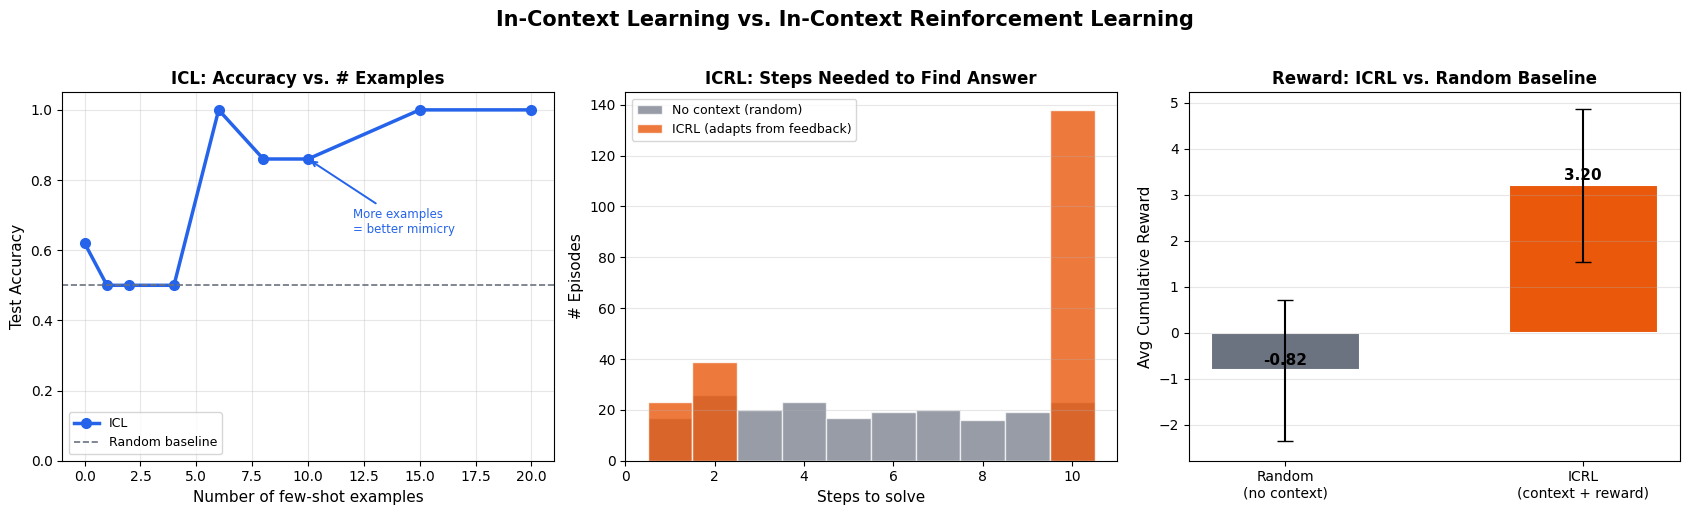


💾 Figure saved as icl_vs_icrl_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('In-Context Learning vs. In-Context Reinforcement Learning',
             fontsize=15, fontweight='bold', y=1.02)

BLUE = '#2563EB'
ORANGE = '#EA580C'
GRAY = '#6B7280'

# ── Plot 1: ICL accuracy vs. number of shots ──
ax = axes[0]
shots = [r['n_shots'] for r in icl_results]
accs  = [r['accuracy'] for r in icl_results]
ax.plot(shots, accs, 'o-', color=BLUE, linewidth=2.5, markersize=7, label='ICL')
ax.axhline(0.5, color=GRAY, linestyle='--', linewidth=1.2, label='Random baseline')
ax.set_xlabel('Number of few-shot examples', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('ICL: Accuracy vs. # Examples', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.annotate('More examples\n= better mimicry', xy=(10, accs[shots.index(10)]),
            xytext=(12, 0.65), fontsize=8.5, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.4))

# ── Plot 2: Steps to solve comparison ──
ax = axes[1]
bins = np.arange(1, 12) - 0.5
ax.hist(rand_steps, bins=bins, alpha=0.7, color=GRAY, label='No context (random)', edgecolor='white')
ax.hist(icrl_steps, bins=bins, alpha=0.8, color=ORANGE, label='ICRL (adapts from feedback)', edgecolor='white')
ax.set_xlabel('Steps to solve', fontsize=11)
ax.set_ylabel('# Episodes', fontsize=11)
ax.set_title('ICRL: Steps Needed to Find Answer', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# ── Plot 3: Reward comparison ──
ax = axes[2]
labels = ['Random\n(no context)', 'ICRL\n(context + reward)']
means  = [np.mean(rand_rewards), np.mean(icrl_rewards)]
stds   = [np.std(rand_rewards),  np.std(icrl_rewards)]
colors = [GRAY, ORANGE]
bars = ax.bar(labels, means, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax.errorbar(labels, means, yerr=stds, fmt='none', color='black', capsize=6, linewidth=1.5)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.05,
            f'{mean:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylabel('Avg Cumulative Reward', fontsize=11)
ax.set_title('Reward: ICRL vs. Random Baseline', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(bottom=min(means) - max(stds) - 0.3)

plt.tight_layout()
plt.savefig('icl_vs_icrl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾 Figure saved as icl_vs_icrl_comparison.png')

---
## 🔄 Part 4: The Loop Difference — The Core Insight

This is the **fundamental** difference:

```
ICL:                          ICRL:
─────────────────────         ────────────────────────────────────
Examples → Predict            while not done:
           ↓                      guess = model.act(history)
          Done                     reward = env.step(guess)
                                   history.append((guess, reward))
No loop.                      ← Loop! The context grows with experience.
No feedback.                  ← Each step is informed by all prior steps.
```

The model's **context window is its memory and its learning**. In ICRL, the context replaces replay buffers, value functions, and policy gradient updates — all done in-context, in a single forward pass per step.

/tmp/ipykernel_931/2095204794.py:33: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_931/2095204794.py:33: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_931/2095204794.py:34: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('context_growth.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_931/2095204794.py:34: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('context_growth.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from fon

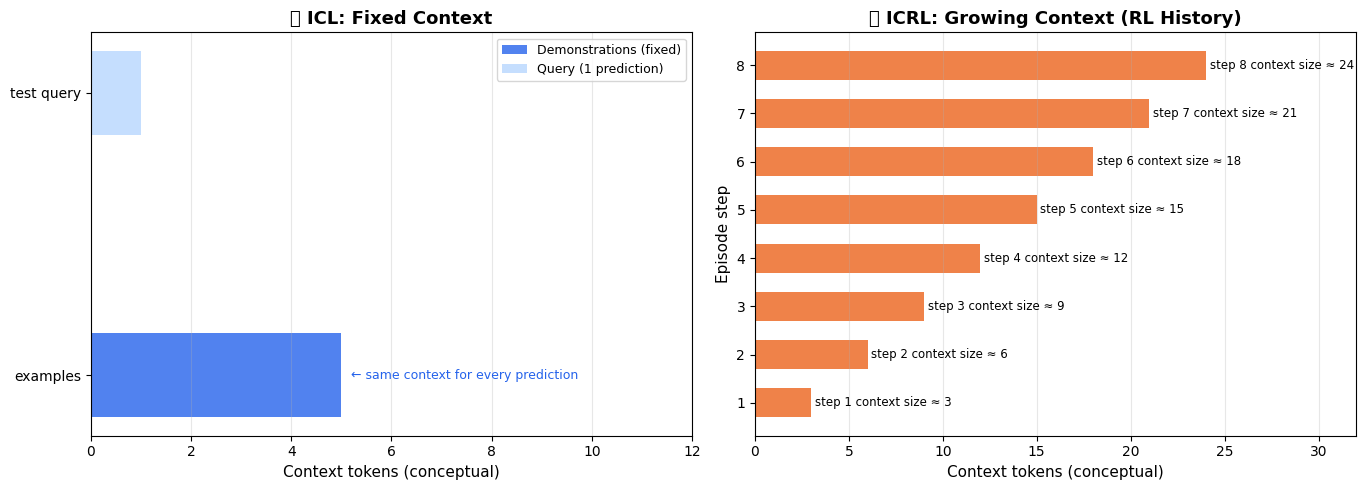

💾 Figure saved as context_growth.png


In [ ]:
# Visualize how context grows during an ICRL episode
# vs. the fixed context in ICL

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
BLUE = '#2563EB'
ORANGE = '#EA580C'

# ── ICL: fixed context ──
ax = axes[0]
n_shots = 5
ax.barh(['examples'], [n_shots], color=BLUE, alpha=0.8, height=0.3, label='Demonstrations (fixed)')
ax.barh(['test query'], [1], color='#BFDBFE', alpha=0.9, height=0.3, label='Query (1 prediction)')
ax.set_xlim(0, 12)
ax.set_xlabel('Context tokens (conceptual)', fontsize=11)
ax.set_title('🔵 ICL: Fixed Context', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='x')
ax.text(5.2, 0.0, '← same context for every prediction', va='center', fontsize=9, color=BLUE)

# ── ICRL: growing context ──
ax = axes[1]
steps = list(range(1, 9))
ctx_sizes = [s * 3 for s in steps]  # each step adds (action, reward, hint) = 3 tokens
ax.barh(steps, ctx_sizes, color=ORANGE, alpha=0.75, height=0.6)
for s, sz in zip(steps, ctx_sizes):
    ax.text(sz + 0.2, s, f'step {s} context size ≈ {sz}', va='center', fontsize=8.5)
ax.set_xlabel('Context tokens (conceptual)', fontsize=11)
ax.set_ylabel('Episode step', fontsize=11)
ax.set_title('🟠 ICRL: Growing Context (RL History)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 32)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('context_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Figure saved as context_growth.png')

---
## 📋 Part 5: Summary Table

In [ ]:
summary = pd.DataFrame({
    'Property': [
        'Learning signal',
        'Context contents',
        'Feedback loop',
        'Adaptation',
        'Weight updates',
        'Primary use case',
        'Key paper / concept',
        'Failure mode',
    ],
    'ICL (In-Context Learning)': [
        'Demonstrations (input→output pairs)',
        'Fixed: k examples + 1 query',
        '❌ None — single forward pass',
        'Pattern matching from examples',
        '❌ No',
        'Classification, translation, QA with examples',
        'GPT-3 few-shot prompting (Brown et al., 2020)',
        'Bad examples → bad predictions (no correction)',
    ],
    'ICRL (In-Context RL)': [
        'Reward signal from environment interactions',
        'Growing: (action, reward, obs)* history',
        '✅ Yes — multi-step trial & error',
        'Strategy refinement via reward history',
        '❌ No (still just inference)',
        'Sequential decision-making, exploration tasks',
        'Algorithm Distillation (Laskin et al., 2022)',
        'Context length limits cap episode depth',
    ]
})

summary = summary.set_index('Property')
display(summary.style
    .set_properties(**{'text-align': 'left', 'font-size': '13px'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#1E3A5F'), ('color', 'white'),
                  ('font-size', '14px'), ('text-align', 'center')]
    }, {
        'selector': 'td:nth-child(2)',
        'props': [('background-color', '#EFF6FF'), ('color', '#1E40AF')]
    }, {
        'selector': 'td:nth-child(3)',
        'props': [('background-color', '#FFF7ED'), ('color', '#9A3412')]
    }])
)

,ICL (In-Context Learning),ICRL (In-Context RL)
Property,,
Learning signal,Demonstrations (input→output pairs),Reward signal from environment interactions
Context contents,Fixed: k examples + 1 query,"Growing: (action, reward, obs)* history"
Feedback loop,❌ None — single forward pass,✅ Yes — multi-step trial & error
Adaptation,Pattern matching from examples,Strategy refinement via reward history
Weight updates,❌ No,❌ No (still just inference)
Primary use case,"Classification, translation, QA with examples","Sequential decision-making, exploration tasks"
Key paper / concept,"GPT-3 few-shot prompting (Brown et al., 2020)","Algorithm Distillation (Laskin et al., 2022)"
Failure mode,Bad examples → bad predictions (no correction),Context length limits cap episode depth


---
## 🎯 Takeaways

1. **ICL** treats the context as a set of **demonstrations** — it mimics patterns. Great for tasks where you have good examples. No feedback loop.

2. **ICRL** treats the context as an **RL history** — the model reads its own past (action, reward) pairs and adapts. The reward signal replaces the need for labeled demonstrations.

3. Both happen **entirely at inference time** — no gradient updates. The transformer is learning to learn, within its context window.

4. ICRL is particularly powerful for **exploration-heavy tasks** where the optimal strategy isn't known in advance but can be discovered through interaction.

### 📚 Further Reading
- Brown et al. (2020) — *"Language Models are Few-Shot Learners"* (GPT-3, the ICL paper)
- Laskin et al. (2022) — *"In-context Reinforcement Learning with Algorithm Distillation"*
- Lee et al. (2023) — *"Supervised Pretraining Can Learn In-Context RL"*
- Chan et al. (2022) — *"Data Distributional Properties Drive Emergent In-Context Learning"*

how did this code perform

The notebook demonstrates the performance of both In-Context Learning (ICL) and In-Context Reinforcement Learning (ICRL) in their respective tasks:

**For In-Context Learning (ICL):**

*   ICL's accuracy improved with more few-shot examples, reaching 100% with 6, 15, and 20 examples for the 'high'/'low' prediction task.
    
*   Even with 0-shots, it achieved 62.0% accuracy, and 50.0% with 1, 2, and 4 shots.
    

**For In-Context Reinforcement Learning (ICRL):**

*   Compared to a random baseline over 200 episodes in the secret number guessing game:
    
    *   **ICRL** achieved an average of **7.41 steps to solve** and an **average reward of 3.20**.
        
    *   The **Random baseline** took an average of **5.45 steps to solve** but had a much lower **average reward of -0.82**.
        

This indicates that while the random strategy might sometimes stumble upon the answer faster in terms of steps, the ICRL agent, by adapting from feedback, consistently achieved a much higher cumulative reward, showing its effectiveness in learning from interactions.

why is a much higher cumulative reward, a good thing

That's a great question! In reinforcement learning, the goal is often to maximize the **cumulative reward** over time, not just to finish the task quickly. Think of it this way:

*   **Higher cumulative reward** means the agent is making better decisions throughout the entire episode, leading to more positive outcomes and fewer negative ones.
    
*   Even if the ICRL agent took slightly more steps on average (7.41 vs. 5.45 for random), its guesses were 'smarter' based on the feedback it received. It avoided actions that led to large negative rewards and often made guesses that resulted in positive rewards (like being 'very close' or 'correct').
    
*   The random agent, while sometimes stumbling upon the answer quickly, also made many 'bad' guesses, leading to significantly negative rewards. Its overall experience was much less positive, as reflected by its average reward of -0.82 compared to ICRL's 3.20.
    

So, a much higher cumulative reward signifies that the ICRL agent is learning to navigate the task more effectively and efficiently in terms of _value_ rather than just _speed_.